In [1]:
import pandas as pd
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    port=3306,
    user="root",
    password="Vishnu2005v",
    database="olist_ecommerce"
)

print("MySQL connection successful!")

MySQL connection successful!


## Load Orders

In [2]:
query = """
SELECT *
FROM orders
"""

orders = pd.read_sql(query, conn)

print("Orders loaded successfully!")
print("Shape:", orders.shape)

orders.head()

C:\Users\Vishnupriyan\AppData\Local\Temp\ipykernel_15476\2730260726.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders = pd.read_sql(query, conn)


Orders loaded successfully!
Shape: (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17


## Order Status Analysis

In [3]:
order_status_counts = orders["order_status"].value_counts()
print(order_status_counts)

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


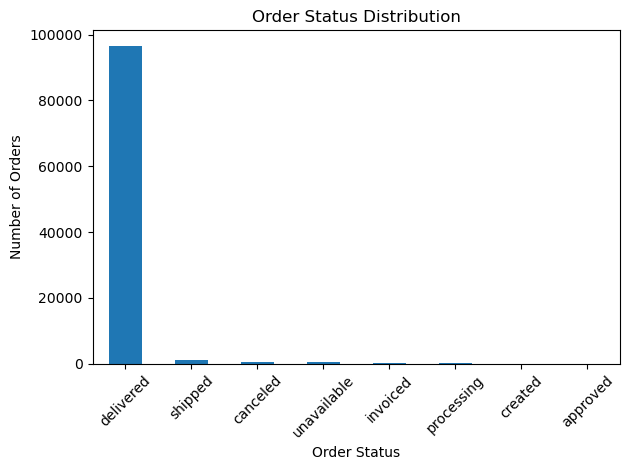

In [4]:
import matplotlib.pyplot as plt

order_status_counts.plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Order Status — percentage

In [5]:
status_percentage = (
    orders["order_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(status_percentage)

order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64


## Review Score Analysis

In [6]:
query = """
SELECT review_score
FROM order_reviews
"""

reviews = pd.read_sql(query, conn)

print("Reviews loaded successfully!")
print(reviews.shape)
print(reviews["review_score"].value_counts().sort_index())

C:\Users\Vishnupriyan\AppData\Local\Temp\ipykernel_15476\2356645899.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  reviews = pd.read_sql(query, conn)


Reviews loaded successfully!
(99224, 1)
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


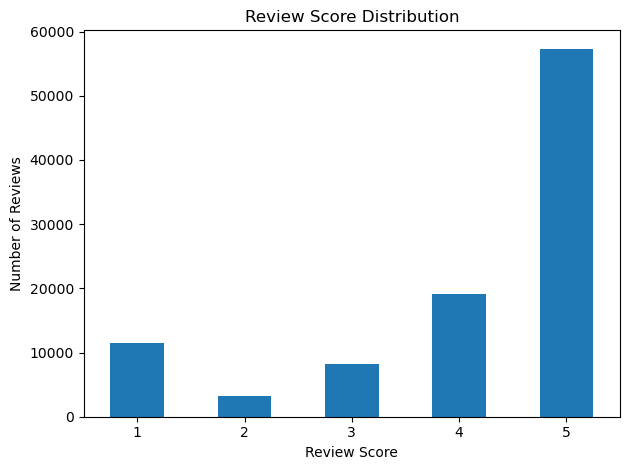

In [7]:
review_counts = reviews["review_score"].value_counts().sort_index()

review_counts.plot(kind="bar")

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
review_percentage = (
    reviews["review_score"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print(review_percentage)

review_score
1    11.51
2     3.18
3     8.24
4    19.29
5    57.78
Name: proportion, dtype: float64


## Order Status vs Review Score

In [9]:
query = """
SELECT
    o.order_status,
    r.review_score
FROM orders o
JOIN order_reviews r
    ON o.order_id = r.order_id
"""

status_reviews = pd.read_sql(query, conn)

print(status_reviews.head())
print(status_reviews.shape)

C:\Users\Vishnupriyan\AppData\Local\Temp\ipykernel_15476\2356878648.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  status_reviews = pd.read_sql(query, conn)


  order_status  review_score
0    delivered             5
1    delivered             4
2    delivered             5
3    delivered             4
4    delivered             5
(99224, 2)


In [10]:
avg_review_by_status = (
    status_reviews
    .groupby("order_status")["review_score"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print(avg_review_by_status)

order_status
delivered      4.16
approved       2.50
created        2.33
shipped        2.01
canceled       1.81
invoiced       1.66
unavailable    1.53
processing     1.28
Name: review_score, dtype: float64


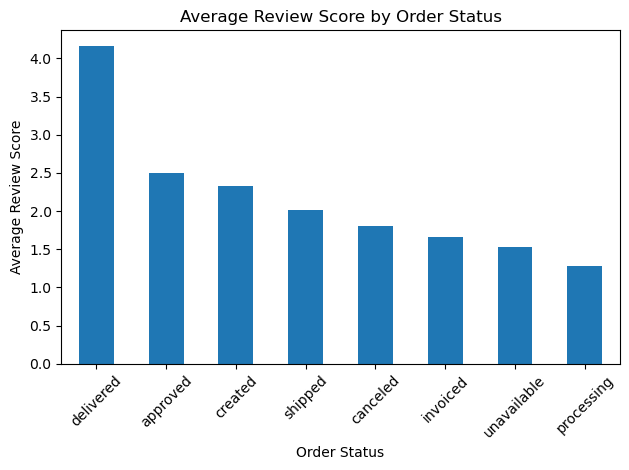

In [11]:
avg_review_by_status.plot(kind="bar")

plt.title("Average Review Score by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Average Review Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Price vs Review Score

In [12]:
query = """
SELECT
    oi.price,
    r.review_score
FROM order_items oi
JOIN order_reviews r
    ON oi.order_id = r.order_id
"""

price_reviews = pd.read_sql(query, conn)

print(price_reviews.head())
print(price_reviews.shape)

C:\Users\Vishnupriyan\AppData\Local\Temp\ipykernel_15476\2343893568.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  price_reviews = pd.read_sql(query, conn)


    price  review_score
0  185.00             4
1  185.00             4
2   79.79             5
3  149.00             5
4  179.99             5
(112372, 2)


## Average Price by Review Score

In [13]:
avg_price_by_review = (
    price_reviews
    .groupby("review_score")["price"]
    .mean()
    .round(2)
)

print(avg_price_by_review)

review_score
1    127.35
2    115.85
3    110.06
4    118.60
5    121.22
Name: price, dtype: float64


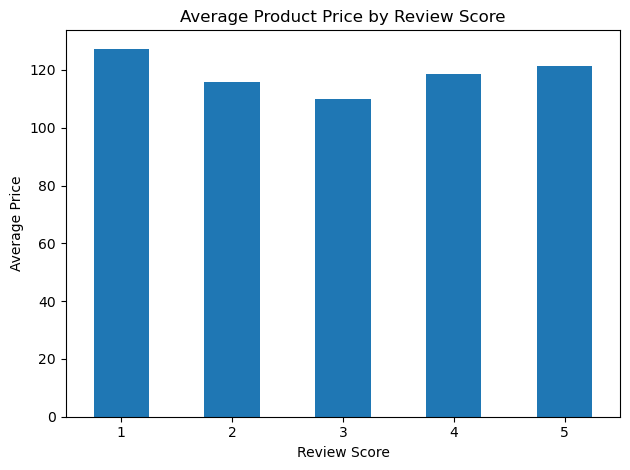

In [14]:
avg_price_by_review.plot(kind="bar")

plt.title("Average Product Price by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Price")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Delivery delay vs Review score

In [15]:
query = """
SELECT
    DATEDIFF(
        order_delivered_customer_date,
        order_estimated_delivery_date
    ) AS delivery_delay,
    r.review_score
FROM orders o
JOIN order_reviews r
    ON o.order_id = r.order_id
WHERE o.order_delivered_customer_date IS NOT NULL
  AND o.order_estimated_delivery_date IS NOT NULL
"""

delay_reviews = pd.read_sql(query, conn)

print(delay_reviews.head())
print(delay_reviews.shape)

C:\Users\Vishnupriyan\AppData\Local\Temp\ipykernel_15476\1802804090.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  delay_reviews = pd.read_sql(query, conn)


   delivery_delay  review_score
0              -9             5
1              -3             4
2             -14             5
3              -6             4
4             -16             5
(96359, 2)


In [16]:
avg_delay_by_review = (
    delay_reviews
    .groupby("review_score")["delivery_delay"]
    .mean()
    .round(2)
)

print(avg_delay_by_review)

review_score
1    -4.06
2    -8.63
3   -10.77
4   -12.38
5   -13.39
Name: delivery_delay, dtype: float64


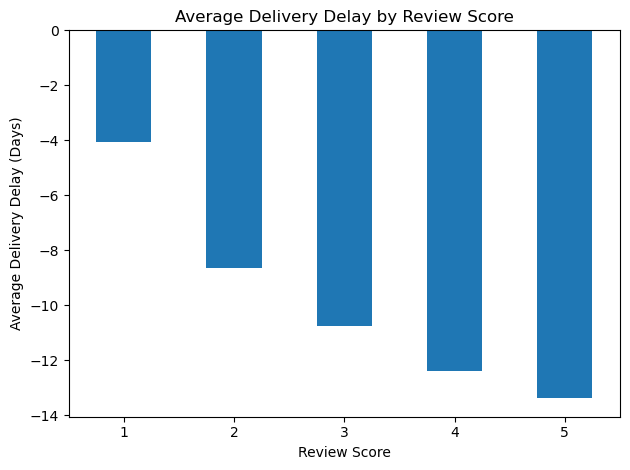

In [17]:
avg_delay_by_review.plot(kind="bar")

plt.title("Average Delivery Delay by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Delay (Days)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Multivariate Analysis

In [18]:
query = """
SELECT
    oi.price,
    oi.freight_value,
    r.review_score
FROM order_items oi
JOIN order_reviews r
    ON oi.order_id = r.order_id
"""

multi_data = pd.read_sql(query, conn)

print(multi_data.head())
print(multi_data.shape)

C:\Users\Vishnupriyan\AppData\Local\Temp\ipykernel_15476\758469915.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  multi_data = pd.read_sql(query, conn)


    price  freight_value  review_score
0  185.00          13.63             4
1  185.00          13.63             4
2   79.79           8.30             5
3  149.00          45.12             5
4  179.99          42.85             5
(112372, 3)


## Compare Price and Freight by Review Score

               price  freight_value
review_score                       
1             127.35          21.21
2             115.85          20.94
3             110.06          20.29
4             118.60          20.05
5             121.22          19.57


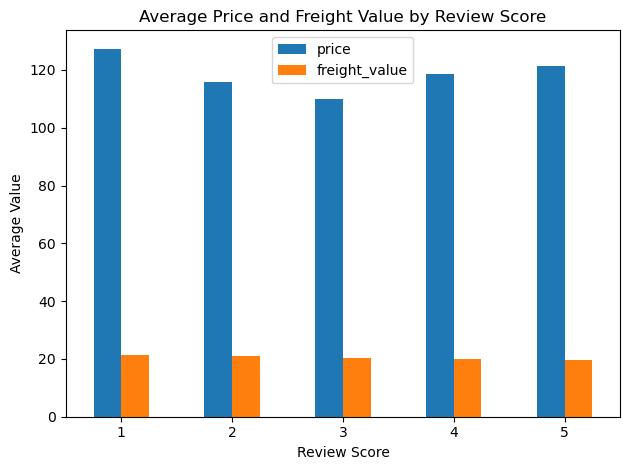

In [19]:
multivariate_summary = (
    multi_data
    .groupby("review_score")[["price", "freight_value"]]
    .mean()
    .round(2)
)

print(multivariate_summary)

multivariate_summary.plot(kind="bar")

plt.title("Average Price and Freight Value by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Trend Analysis

C:\Users\Vishnupriyan\AppData\Local\Temp\ipykernel_15476\973534162.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly_trend = pd.read_sql(query, conn)


     month  total_orders  total_order_value
0  2016-09             3             267.36
1  2016-10           308           49507.66
2  2016-12             1              10.90
3  2017-01           789          120312.87
4  2017-02          1733          247303.02


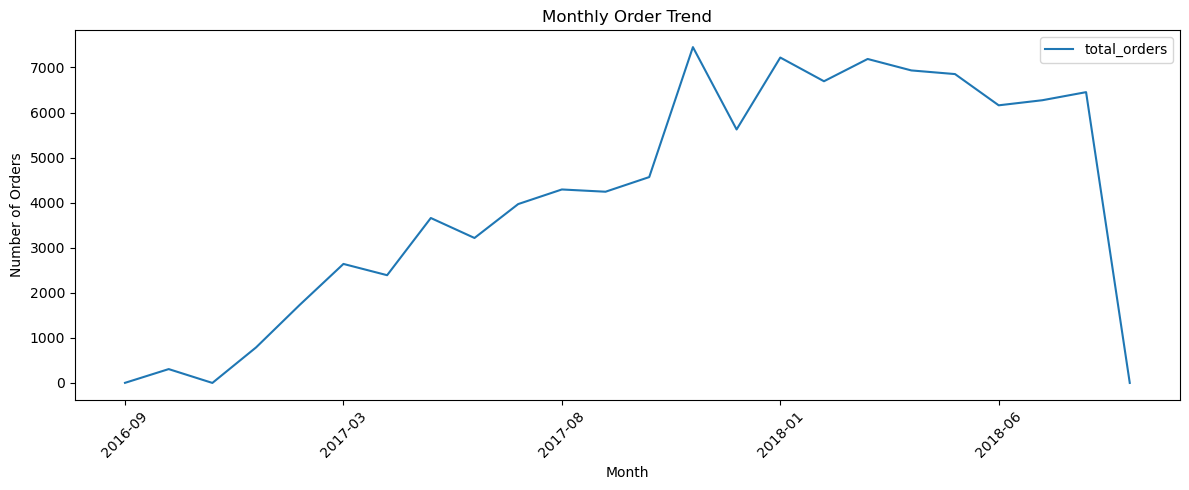

In [21]:
query = """
SELECT
    DATE_FORMAT(o.order_purchase_timestamp, '%Y-%m') AS month,
    COUNT(DISTINCT o.order_id) AS total_orders,
    SUM(oi.price) AS total_order_value
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
GROUP BY DATE_FORMAT(o.order_purchase_timestamp, '%Y-%m')
ORDER BY month
"""

monthly_trend = pd.read_sql(query, conn)

print(monthly_trend.head(5))

monthly_trend.plot(
    x="month",
    y="total_orders",
    kind="line",
    figsize=(12, 5)
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Correlation Analysis

               price  freight_value  review_score
price           1.00           0.41         -0.00
freight_value   0.41           1.00         -0.04
review_score   -0.00          -0.04          1.00


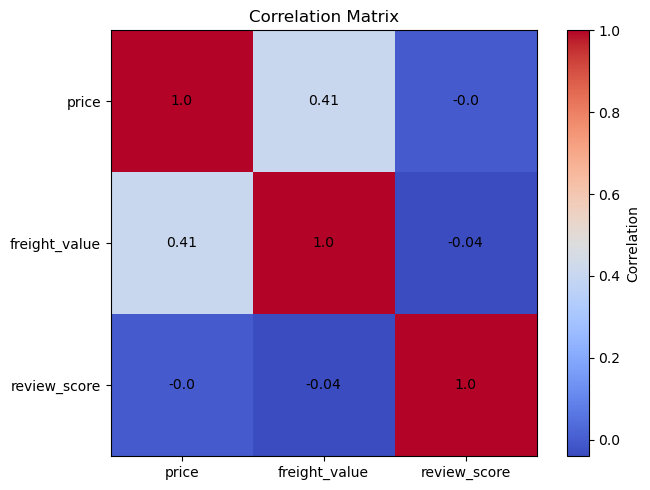

In [22]:
correlation = multi_data[["price", "freight_value", "review_score"]].corr().round(2)

print(correlation)

plt.figure(figsize=(7, 5))
plt.imshow(correlation, cmap="coolwarm")

plt.xticks(range(len(correlation.columns)), correlation.columns)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.colorbar(label="Correlation")
plt.title("Correlation Matrix")

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(j, i, correlation.iloc[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## Distribution Analysis

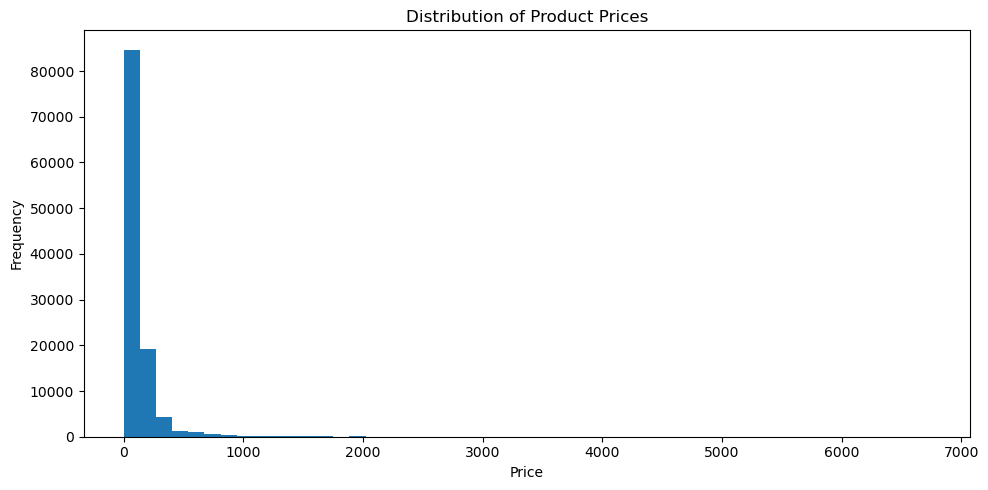

In [23]:
plt.figure(figsize=(10, 5))

plt.hist(multi_data["price"], bins=50)

plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Key Insights

- 97.02% of orders were delivered successfully.
- 5-star reviews represented the largest share of reviews at 57.78%.
- Delivered orders had the highest average review score of 4.16.
- Average product price did not show a clear relationship with review score.
- Higher review scores were associated with earlier delivery compared with the estimated delivery date.
- Monthly order volume showed strong growth over the observed period.
- Price and freight value had a moderate positive correlation of 0.41.
- Review score had almost no linear correlation with price or freight value.
- Product prices showed a right-skewed distribution, with most products concentrated at lower price ranges.